# **Wild Blueberry Yield Prediction using Machine Learning (ML) Algorithms**

*A predictive modeling of an open-source **Wild Blueberry Pollination Simulation** dataset using multiple ML models!*

## **Setup and Data Loading**

In [1]:
# --- Import necessary libraries ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import joblib       # For saving and loading the trained model

# Import the machine learning models:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

# Set some display options for pandas for better readability:
pd.set_option('display.max_columns', None)

In [2]:
# --- Load the Dataset ---

try:
    df = pd.read_csv('WildBlueberryPollinationSimulationData.csv')
    print("Data Loaded Successfully!")
except FileNotFoundError:
    print("Error: The file 'WildBlueberryPollinationSimulationData.csv' was not found.")
    print("Please make sure it's in the correct folder.")
    
# Display the first 5 rows to understand the data:
print("\n--- Data Preview ---")
print(df.head())

# Get the shape of the dataset:
print("\nData Shape:", df.shape)

# Get a quick summary of all columns, their types, and non-null counts:
print("\n--- Data Info ---")
df.info()

Data Loaded Successfully!

--- Data Preview ---
   Row#  clonesize  honeybee  bumbles  andrena  osmia  MaxOfUpperTRange  \
0     0       37.5      0.75     0.25     0.25   0.25              86.0   
1     1       37.5      0.75     0.25     0.25   0.25              86.0   
2     2       37.5      0.75     0.25     0.25   0.25              94.6   
3     3       37.5      0.75     0.25     0.25   0.25              94.6   
4     4       37.5      0.75     0.25     0.25   0.25              86.0   

   MinOfUpperTRange  AverageOfUpperTRange  MaxOfLowerTRange  MinOfLowerTRange  \
0              52.0                  71.9              62.0              30.0   
1              52.0                  71.9              62.0              30.0   
2              57.2                  79.0              68.2              33.0   
3              57.2                  79.0              68.2              33.0   
4              52.0                  71.9              62.0              30.0   

   AverageOfLo

## **Data Cleaning and Preprocessing**

Total Missing Values in the Dataset: 0

--- Top 10 Correlations with Yield ---
yield               1.000000
fruitset            0.984081
seeds               0.961249
fruitmass           0.930365
osmia               0.380892
bumbles             0.309407
andrena             0.140277
Row#               -0.024942
honeybee           -0.044250
MinOfUpperTRange   -0.175883
Name: yield, dtype: float64


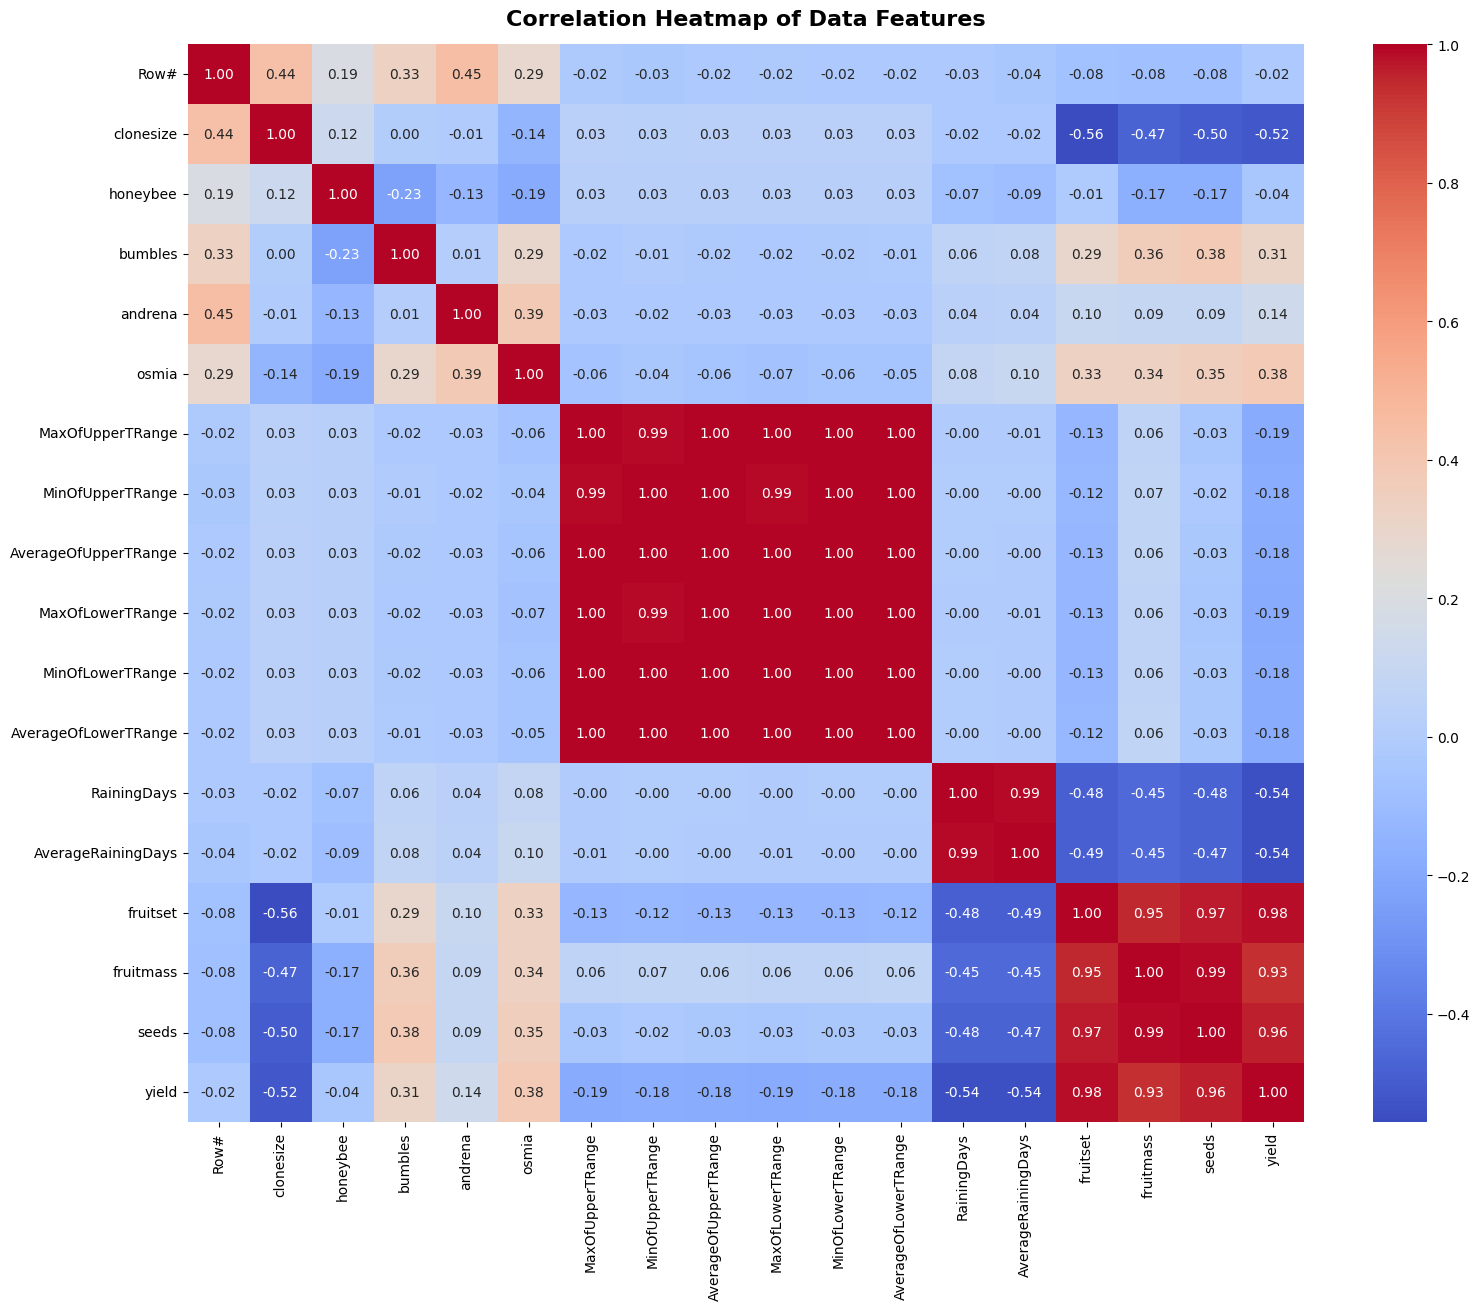

In [3]:
# --- Exploratory Data Analysis (EDA) ---

# Check for missing values:
print(f"Total Missing Values in the Dataset: {df.isnull().sum().sum()}")

# Correlations Matrix with target variable 'Yield':
corr_matrix = df.corr()
print("\n--- Top 10 Correlations with Yield ---")
print(corr_matrix['yield'].sort_values(ascending=False).head(10))

# Plot a heatmap for correlation matrix:
plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', annot_kws={"size": 10})
plt.title('Correlation Heatmap of Data Features', y=1.01, fontsize=16, weight='bold')
plt.show()

In [4]:
# --- Data Cleaning ---

# Drop the irrelevant Row# column:
df_cleaned = df.drop('Row#', axis=1)

# Drop the data leakage columns:
leakage_cols = ['fruitset', 'fruitmass', 'seeds']
df_cleaned = df_cleaned.drop(leakage_cols, axis=1)

print("--- DataFrame after Dropping Irrelevant & Leakage Columns ---\n")
print(df_cleaned.head())

--- DataFrame after Dropping Irrelevant & Leakage Columns ---

   clonesize  honeybee  bumbles  andrena  osmia  MaxOfUpperTRange  \
0       37.5      0.75     0.25     0.25   0.25              86.0   
1       37.5      0.75     0.25     0.25   0.25              86.0   
2       37.5      0.75     0.25     0.25   0.25              94.6   
3       37.5      0.75     0.25     0.25   0.25              94.6   
4       37.5      0.75     0.25     0.25   0.25              86.0   

   MinOfUpperTRange  AverageOfUpperTRange  MaxOfLowerTRange  MinOfLowerTRange  \
0              52.0                  71.9              62.0              30.0   
1              52.0                  71.9              62.0              30.0   
2              57.2                  79.0              68.2              33.0   
3              57.2                  79.0              68.2              33.0   
4              52.0                  71.9              62.0              30.0   

   AverageOfLowerTRange  RainingDay

In [5]:
# --- Statistical Summary of Cleaned Dataset ---

def create_statistical_summary(df):
    stats_dict = {
        'Count': df.count(),
        'Min': df.min(),
        'Max': df.max(), 
        'Mean': df.mean(),
        'SD': df.std(),
        'Variance': df.var()
    }
    
    # Save to a DataFrame for better display:
    stats_df = pd.DataFrame(stats_dict)
    
    # Format the numerical columns for better readability:
    stats_df['Min'] = stats_df['Min'].round(2)
    stats_df['Max'] = stats_df['Max'].round(2)
    stats_df['Mean'] = stats_df['Mean'].round(3)
    stats_df['SD'] = stats_df['SD'].round(4)
    stats_df['Variance'] = stats_df['Variance'].round(3)
    
    return stats_df

# Create and display the statistical summary:
print("--- Statistical Summary of Cleaned Dataset---")
statistical_summary = create_statistical_summary(df_cleaned)
print(statistical_summary)

--- Statistical Summary of Cleaned Dataset---
                      Count      Min      Max      Mean         SD  \
clonesize               777    10.00    40.00    18.768     6.9991   
honeybee                777     0.00    18.43     0.417     0.9789   
bumbles                 777     0.00     0.58     0.282     0.0663   
andrena                 777     0.00     0.75     0.469     0.1611   
osmia                   777     0.00     0.75     0.562     0.1691   
MaxOfUpperTRange        777    69.70    94.60    82.277     9.1937   
MinOfUpperTRange        777    39.00    57.20    49.701     5.5958   
AverageOfUpperTRange    777    58.20    79.00    68.723     7.6770   
MaxOfLowerTRange        777    50.20    68.20    59.309     6.6478   
MinOfLowerTRange        777    24.30    33.00    28.690     3.2095   
AverageOfLowerTRange    777    41.20    55.90    48.613     5.4171   
RainingDays             777     1.00    34.00    18.309    12.1242   
AverageRainingDays      777     0.06     0.5

# **Features Selection**

In [6]:
# --- Define X and Y ---

# Define the target variable:
Y = df_cleaned['yield']

# Define the feature variables:
feature_cols = [
    'clonesize', 
    'honeybee', 
    'bumbles', 
    'andrena', 
    'osmia', 
    'MaxOfUpperTRange', 
    'RainingDays'
]

X = df_cleaned[feature_cols]

# Display the final features (X) and target (Y):
print("--- Final Features (X) ---")
print(X.head())

print("\n--- Final Target (Y) ---")
print(Y.head())

--- Final Features (X) ---
   clonesize  honeybee  bumbles  andrena  osmia  MaxOfUpperTRange  RainingDays
0       37.5      0.75     0.25     0.25   0.25              86.0         16.0
1       37.5      0.75     0.25     0.25   0.25              86.0          1.0
2       37.5      0.75     0.25     0.25   0.25              94.6         16.0
3       37.5      0.75     0.25     0.25   0.25              94.6          1.0
4       37.5      0.75     0.25     0.25   0.25              86.0         24.0

--- Final Target (Y) ---
0    3813.165795
1    4947.605663
2    3866.798965
3    4303.943030
4    3436.493543
Name: yield, dtype: float64


# **Splitting the Data**

In [7]:
# --- Train/Test Split ---

# Split the data into 80% training and 20% testing sets:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(f"Complete Data Shape: {X.shape}")
print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape: {X_test.shape}")

Complete Data Shape: (777, 7)
Training Data Shape: (621, 7)
Testing Data Shape: (156, 7)


## **Model Training and Evaluation**

---

### **Model 1: Multiple Linear Regression (MLR)**

In [8]:
print("--- Training Model 1: Multiple Linear Regression (MLR) ---")

# Initialize the model:
mlr_model = LinearRegression()

# Train (fit) the model on the training data:
mlr_model.fit(X_train, Y_train)

# Make predictions on the unseen test data:
y_pred_mlr = mlr_model.predict(X_test)

# Evaluate the model:
rmse_mlr = np.sqrt(mean_squared_error(Y_test, y_pred_mlr))
r2_mlr = r2_score(Y_test, y_pred_mlr)

print(f"\nRoot Mean Square Error (RMSE): {rmse_mlr:.2f}")
print(f"Coefficient of Determination (R²): {r2_mlr:.4f} ({r2_mlr*100:.2f}%)")

--- Training Model 1: Multiple Linear Regression (MLR) ---

Root Mean Square Error (RMSE): 579.29
Coefficient of Determination (R²): 0.8273 (82.73%)


### **Model 2: Random Forest Regressor (RF)**

In [9]:
print("--- Training Model 2: Random Forest (RF) ---")

# Initialize the model:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model:
rf_model.fit(X_train, Y_train)

# Make predictions on the unseen test data:
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model:
rmse_rf = np.sqrt(mean_squared_error(Y_test, y_pred_rf))
r2_rf = r2_score(Y_test, y_pred_rf)

print(f"\nRoot Mean Square Error (RMSE): {rmse_rf:.2f}")
print(f"Coefficient of Determination (R²): {r2_rf:.4f} ({r2_rf*100:.2f}%)")

--- Training Model 2: Random Forest (RF) ---

Root Mean Square Error (RMSE): 427.72
Coefficient of Determination (R²): 0.9059 (90.59%)


### **Model 3: Extreme Gradient Boosting (XGBoost)**

In [10]:
print("--- Training Model 3: Extreme Gradient Boosting (XGBoost) ---")

# Initialize the model:
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)

# Train the model:
xgb_model.fit(X_train, Y_train)

# Make predictions:
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the model:
rmse_xgb = np.sqrt(mean_squared_error(Y_test, y_pred_xgb))
r2_xgb = r2_score(Y_test, y_pred_xgb)

print(f"\nRoot Mean Square Error (RMSE): {rmse_xgb:.2f}")
print(f"Coefficient of Determination (R²): {r2_xgb:.4f} ({r2_xgb*100:.2f}%)")

--- Training Model 3: Extreme Gradient Boosting (XGBoost) ---

Root Mean Square Error (RMSE): 346.08
Coefficient of Determination (R²): 0.9384 (93.84%)


## **Model Comparison & Conclusion**

In [11]:
print("---- Model Performance Comparison ----")

results_df = pd.DataFrame({
    'Model': ['Multiple Linear Regression', 'Random Forest', 'XGBoost'],
    'RMSE': [rmse_mlr, rmse_rf, rmse_xgb],
    'R²': [r2_mlr, r2_rf, r2_xgb]
})

# Display model comparison sorted by RMSE:
results_df.sort_values(by='RMSE', ascending=True)

---- Model Performance Comparison ----


,Model,RMSE,R²
2,XGBoost,346.084235,0.938376
1,Random Forest,427.718321,0.905876
0,Multiple Linear Regression,579.286160,0.827347


C:\Users\General\AppData\Local\Temp\ipykernel_5008\764891282.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()


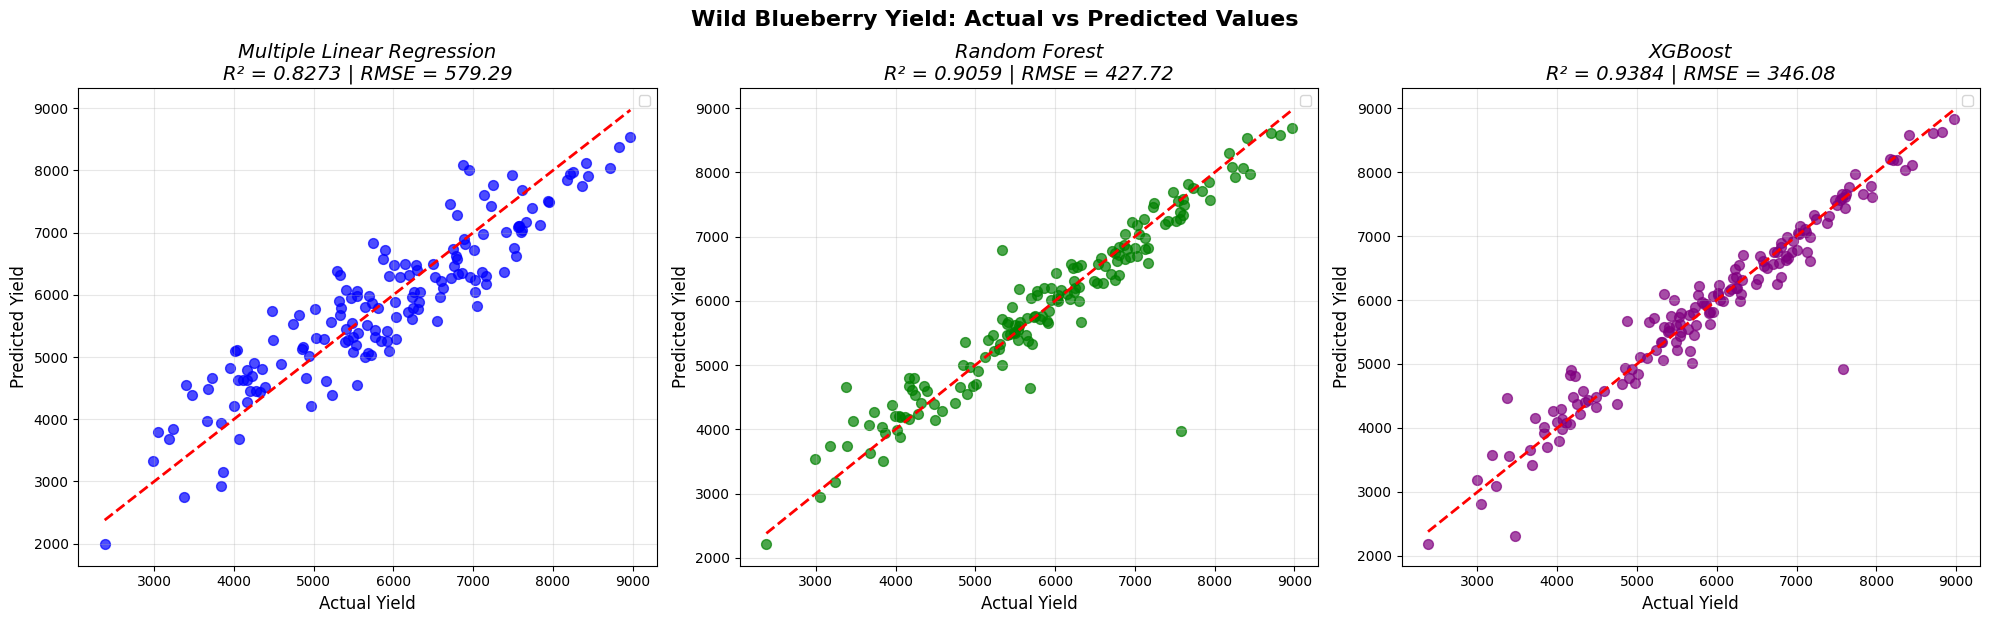

In [12]:
# Actual vs Predicted Values Comparison across each Model:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# List of models and their predictions:
models_info = [
    (y_pred_mlr, 'Multiple Linear Regression', 'blue', r2_mlr, rmse_mlr),
    (y_pred_rf, 'Random Forest', 'green', r2_rf, rmse_rf),
    (y_pred_xgb, 'XGBoost', 'purple', r2_xgb, rmse_xgb)
]

# Scatter Plots with Trendline:
for i, (y_pred, model_name, color, r2, rmse) in enumerate(models_info):
    axes[i].scatter(Y_test, y_pred, alpha=0.7, color=color, s=50)
    axes[i].plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', lw=2)
    axes[i].set_xlabel('Actual Yield', fontsize=12)
    axes[i].set_ylabel('Predicted Yield', fontsize=12)
    axes[i].set_title(f'{model_name}\nR² = {r2:.4f} | RMSE = {rmse:.2f}', fontsize=14, fontstyle='italic')
    axes[i].grid(True, alpha=0.3)
    axes[i].legend()

plt.tight_layout()
plt.suptitle('Wild Blueberry Yield: Actual vs Predicted Values', y=1.03, fontsize=16, fontweight='bold')
plt.show()

## **Feature Importance**

--- XGBoost Feature Importance ---
            Feature  Importance Score
0         clonesize          0.364604
6       RainingDays          0.232703
4             osmia          0.135495
5  MaxOfUpperTRange          0.119469
2           bumbles          0.083440
1          honeybee          0.053438
3           andrena          0.010852


C:\Users\General\AppData\Local\Temp\ipykernel_5008\4224119987.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance Score', y='Feature', data=importance_df, palette='viridis')


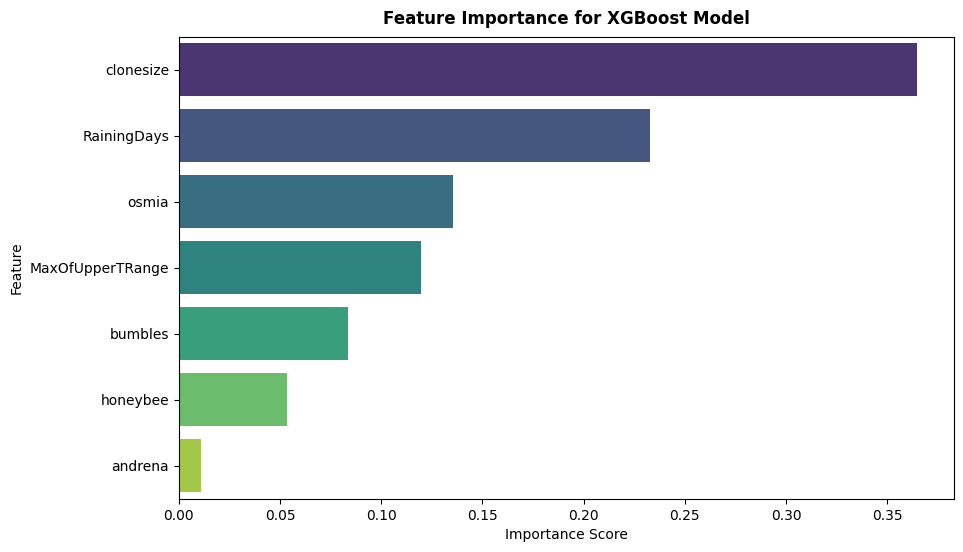

In [13]:
# Get the feature importance scores from the trained XGBoost model:
importance_scores = xgb_model.feature_importances_

# Create a DataFrame to make it easy to view and sort:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance Score': importance_scores
})

# Sort by importance:
importance_df = importance_df.sort_values(by='Importance Score', ascending=False)

print("--- XGBoost Feature Importance ---")
print(importance_df)

# Plot the feature importance:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance Score', y='Feature', data=importance_df, palette='viridis')
plt.title('Feature Importance for XGBoost Model', y=1.01, weight='bold')
plt.show()

## **Model Persistence**

In [14]:
# --- Save the Best Model (Real-World Application) ---

print("--- Saving the Best Model - XGBoost ---")

# Define the filename for our model:
model_filename = 'blueberry_yield_model.joblib'

# Save the model object (xgb_model) to the file:
joblib.dump(xgb_model, model_filename)

print(f"Model Saved Successfully as: '{model_filename}'!")

--- Saving the Best Model - XGBoost ---
Model Saved Successfully as: 'blueberry_yield_model.joblib'!


In [ ]:
# --- Load and Apply the Best Model ---

print("--- Loading the Best Model for New Predictions ---")

# Load the model from the file:
try:
    loaded_model = joblib.load(model_filename)
    print("Model Loaded Successfully!")

    # Create some new, hypothetical data for prediction:    
    new_data = pd.DataFrame({
        'clonesize': [20.0],          # 20 m^2 clone size
        'honeybee': [0.5],           # 0.5 honeybees/m^2/min
        'bumbles': [0.25],           # 0.25 bumbles/m^2/min
        'andrena': [0.38],           # 0.38 andrena/m^2/min
        'osmia': [0.6],              # 0.6 osmia/m^2/min
        'MaxOfUpperTRange': [75.0],  # 75°F max temp
        'RainingDays': [10.0]        # 10 raining days
    })
    
    print("\n--- New Hypothetical Data ---")
    print(new_data)

    # Use the loaded model to make a prediction:
    new_prediction = loaded_model.predict(new_data)
    
    print(f"\nPredicted Yield with XGBoost: {new_prediction[0]:.2f} kg/ha")

except FileNotFoundError:
    print(f"Error: Model file '{model_filename}' not found.")
    print("Please run the previous cell to save the model first.")


--- Loading the Best Model for New Predictions ---
Model Loaded Successfully!

--- New Hypothetical Data ---
   clonesize  honeybee  bumbles  andrena  osmia  MaxOfUpperTRange  RainingDays
0       20.0       0.5     0.25     0.38    0.6              75.0         10.0

Predicted Yield with XGBoost: 5520.53 kg/ha
